In [67]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [68]:
relevant_cols = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]
early_age = 50

data_path = os.path.abspath("../data/tcga_data2.csv")
raw_df = pd.read_csv(data_path, sep = '\t', low_memory = False)
raw_df.head(1)

,Gene,Study of Origin,Sample ID,Cancer Type,Cancer Type Detailed,Protein Change,Annotation,Custom Driver,Custom Driver Tiers,Functional Impact,...,Tumor Type,Used in Genomic Analysis,Vascular invasion indicator,Vessel Invasion,Vial number,Patient's Vital Status,Patient Weight,WGD,Winter Hypoxia Score,Year of Diagnosis
0,APC,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA-AA-A010-01,Colorectal Cancer,Colon Adenocarcinoma,A2D,"OncoKB: Unknown, level NA, resistance NA;reVUE...",NaN,NaN,MutationAssessor: NA;SIFT: impact: deleterious...,...,NaN,NaN,NO,NaN,A,NaN,NaN,NaN,NaN,NaN


In [69]:
def groupby_age(df):
    cols = np.array(df.columns.tolist())
    pattern = re.compile(r'\bage\b', flags = re.IGNORECASE)
    age_cols = np.array([col for col in cols if pattern.search(col) and "Diagnosis" in col])
    df.loc[:, 'Age'] = df[age_cols].bfill(axis = 1).iloc[:, 0]
    df = df.drop(columns = age_cols)
    return df

In [70]:
def columns(df, relevant_cols):
    necessary_cols = ['Sample ID','HGVSc']
    if set(relevant_cols).intersection(necessary_cols) == set(necessary_cols):
        good_cols = np.concatenate((relevant_cols, ['Age']))
        new_df = df[good_cols].copy()
        return new_df
    else:
        raise ValueError("Relevant columns must contain sample ID and HGVSc")

In [71]:
def strip_strings(df):
    df.columns = df.columns.str.strip()
    return df

In [72]:
def remove_duplicates(df):
    df = df.dropna(subset = ["Age"], axis = 0)
    df = df.drop_duplicates(subset = ["Sample ID", "HGVSc"], keep = "first")
    return df

In [73]:
def early_onset(df, early_age):
    df = df.copy()
    df["Early Onset"] = df["Age"] < early_age
    return df

In [74]:
pipeline = (raw_df
    .pipe(groupby_age)
    .pipe(columns, relevant_cols = relevant_cols)
    .pipe(remove_duplicates)
    .pipe(early_onset, early_age = early_age)
           )

pipeline.head(1)

,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
0,APC,TCGA-AA-A010-01,Colon Adenocarcinoma,Missense_Mutation,SNP,ENST00000257430.4:c.5C>A,Somatic,A2D,MutationAssessor: NA;SIFT: impact: deleterious...,46.0,True


---
Extra functions

---

In [75]:
def early_onset_df(df, early_age):
    df = df.copy()
    df["Early Onset"] = df["Age"] < early_age
    df = df[df["Early Onset"] == True]
    return df

In [76]:
def find_gene(df, gene):
    return df[df["HGVSc"] == gene]

---
Trying to find a null cohort - Lung Cancer Data

---

In [77]:
data_path = os.path.abspath("../data/lung_data.csv")
lung_df = pd.read_csv(data_path, low_memory = False)
new_pipeline = (lung_df
    .pipe(strip_strings)
    .pipe(groupby_age)
    .pipe(columns, relevant_cols = relevant_cols)
    .pipe(remove_duplicates)
    .pipe(early_onset, early_age = early_age)
           )
new_pipeline.head(1)

,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
7,APC,LUAD-NYU408,Lung Adenocarcinoma,Splice_Site,SNP,ENST00000257430.4:c.1744-2A>G,Unknown,X582_splice,MutationAssessor: NA;SIFT: NA;Polyphen-2: NA;A...,71.0,False


In [78]:
crc_df = early_onset_df(pipeline, 50)
crc_df.head(1)

,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
0,APC,TCGA-AA-A010-01,Colon Adenocarcinoma,Missense_Mutation,SNP,ENST00000257430.4:c.5C>A,Somatic,A2D,MutationAssessor: NA;SIFT: impact: deleterious...,46.0,True


--- 
Random sample of 35 samples without the mutation.

---

In [79]:
find_gene(new_pipeline, "ENST00000257430.4:c.835-8A>G").shape 

(0, 11)

In [80]:
null = new_pipeline.sample(n=35)
print(null.shape)
null.head(1)

(35, 11)


,Gene,Sample ID,Cancer Type Detailed,Mutation Type,Variant Type,HGVSc,MS,Protein Change,Functional Impact,Age,Early Onset
692,APC,P-0023568-T01-IM6,Poorly Differentiated Non-Small Cell Lung Cancer,Missense_Mutation,SNP,ENST00000257430.4:c.2208G>T,SOMATIC,K736N,"MutationAssessor: impact: medium, score: 6.398...",67.0,False


--- 
Attempting the Mann Whitney U Test

---

"Mann-Whitney is a non-parametric hypothesis test used to assess the difference between two independent samples of continuous or ordinal data"

- **Null Hypothesis $H_0$**: The two populations are equal, there is no significant difference between the groups
- **Alternative Hypothesis $H_1$**: The two populations are not equal, at least one group has signficantly different values.

The test is appropriate when:
- The data is ordinal _but does not follow the normal distribution_
- Two independent groups
- Small sample size (usually between 5 and 30 samples in each group)
- Distributions have similar shapes

In [88]:
from scipy.stats import mannwhitneyu
from scipy.stats import norm

In [82]:
def perform_MWU(sample1, sample2, alpha, verbose = True):
    stat, p_value = mannwhitneyu(sample1, sample2)
    rejected = p_value < alpha

    if verbose:
        print('Statistics=%.2f, p=%.5f' % (stat, p_value))
        if rejected:
            print('Reject Null Hypothesis (Significant difference between two samples)')
        else:
            print('Do not Reject Null Hypothesis (No significant difference between two samples)')
    else:
        return rejected

Between a random sample of people with CRC that do not have the mutation, and those that do have the mutation.

In [83]:
# Generate a cohort of CRC samples that do not contain the mutation
no_mutation = pipeline[pipeline["HGVSc"] != "ENST00000257430.4:c.835-8A>G"]
no_mutation_sample = no_mutation.sample(n=35)
no_mutation_sample = no_mutation_sample["Age"].tolist()

# Generate the cohort of samples that do contain the mutation
mutation = find_gene(pipeline, "ENST00000257430.4:c.835-8A>G")
mutation_sample = mutation["Age"].tolist()

print(f"CRC null cohort size: {len(no_mutation_sample)}, CRC mutation cohort size: {len(mutation_sample)}")

CRC null cohort size: 35, CRC mutation cohort size: 35


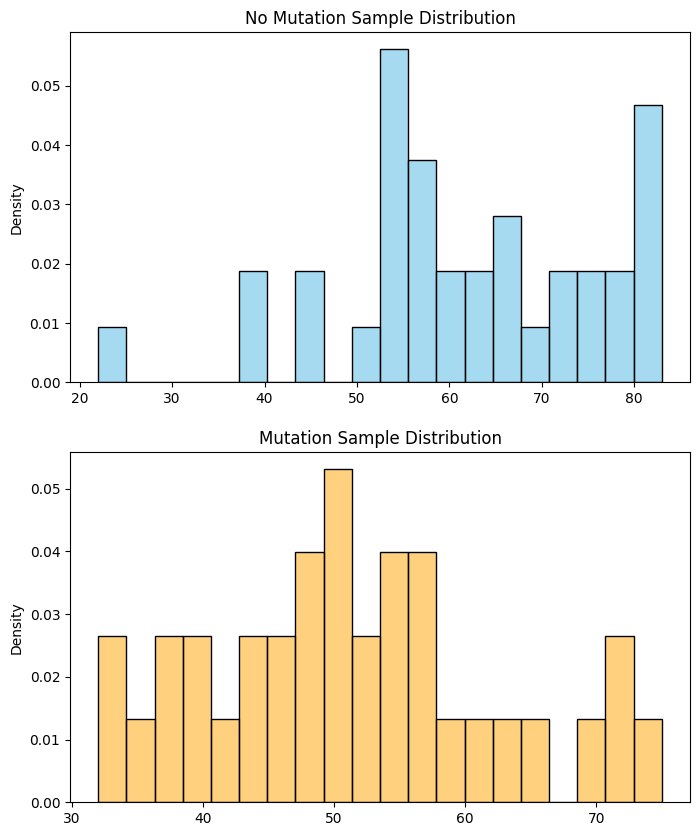

In [96]:
fig, ax = plt.subplots(2, 1, figsize = (8, 10))

sns.histplot(no_mutation_sample, stat = "density", color = 'skyblue', bins = 20, ax = ax[0])
ax[0].set_title("No Mutation Sample Distribution")
sns.histplot(mutation_sample, stat = "density", color = 'orange', bins = 20, alpha =0.5, ax = ax[1])
ax[1].set_title("Mutation Sample Distribution")

plt.show()

In [51]:
# Perform Mann Whitney U Test
perform_MWU(no_mutation_sample, mutation_sample, 0.05)

Statistics=883.00, p=0.00151
Reject Null Hypothesis (Significant difference between two samples)


In [63]:
def run_simulation(sample1, sample2, alpha =0.05, n_iterations = 100, sample_size = 35):
    rejections = 0
    for _ in range(n_iterations):
        rejection = perform_MWU(
            sample1.sample(n=sample_size)["Age"].tolist(),
            sample2.sample(n=sample_size)["Age"].tolist(),
            alpha,
            verbose = False
        )
        rejections += rejection

    print(f"Rejections: {rejections} in {n_iterations} tests")

In [66]:
run_simulation(no_mutation, mutation, alpha =0.05, n_iterations = 100, sample_size = 35)

Rejections: 100 in 100 tests


Between null cohort (lung cancer) and group that contains the mutation from E.Coli (I'm not sure this is statistically useful)

In [33]:
sample1 = null
sample2 = find_gene(pipeline, "ENST00000257430.4:c.835-8A>G")
print(f"Null cohort size: {sample1.shape[0]}, CRC cohort size: {sample2.shape[0]}")

Null cohort size: 35, CRC cohort size: 35


In [34]:
# Convert to list
sample1_age = sample1["Age"].tolist()
sample2_age = sample2["Age"].tolist()

In [35]:
perform_MWU(sample1_age, sample2_age, 0.05)

Statistics=1007.00, p=0.00000
Reject Null Hypothesis (Significant difference between two samples)
